# Temperature, top-p, top-k: a visual guide to sampling

**The Agent Build Log · Build #002 · GenAI & LLM Foundations 2/8**

[Build #001](../01-tokens-and-embeddings/) showed that a model reads **token IDs**. This build shows what it
*writes*: at every step it produces a probability for every token in its vocabulary, and a **sampling
strategy** picks one. Temperature, top-k and top-p are the knobs on that picker.

1. [The model's real menu](#1-the-models-real-menu): next-token probabilities, measured
2. [Temperature reshapes the menu](#2-temperature-reshapes-the-menu)
3. [top-k vs top-p: who gets to stay](#3-top-k-vs-top-p-who-gets-to-stay)
4. [Same prompt, 8 settings, 10 samples each](#4-same-prompt-8-settings-10-samples-each)
5. [When you can't set temperature at all](#5-when-you-cant-set-temperature-at-all)
6. [Findings](#6-findings)

**Cost to run: $0. No API key.** Uses [Qwen2.5-0.5B](https://huggingface.co/Qwen/Qwen2.5-0.5B), a small open model
that runs on a laptop CPU (first run downloads ~1 GB). Every number comes from this model, so other models will
give different numbers but the same shapes.

In [1]:
import json, math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

pd.set_option("display.width", 140); pd.set_option("display.max_colwidth", 80)
CFG = json.loads(Path("data/prompts.json").read_text())
MODEL = "Qwen/Qwen2.5-0.5B"
tok = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch.float32).eval()
print(f"{MODEL}: vocabulary of {len(tok):,} tokens")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen/Qwen2.5-0.5B: vocabulary of 151,665 tokens


## 1. The model's real menu

Give the model a prompt and look at the probabilities it assigns to the **next** token, before any sampling.

In [2]:
@torch.no_grad()
def next_token_logits(prompt: str) -> torch.Tensor:
    ids = tok(prompt, return_tensors="pt").input_ids
    return model(ids).logits[0, -1]          # one score per vocabulary token

def top_table(logits, k=8, temperature=1.0):
    probs = torch.softmax(logits / temperature, dim=-1)
    p, i = probs.topk(k)
    return pd.DataFrame({"token": [repr(tok.decode([t])) for t in i.tolist()],
                         "probability": [round(x, 3) for x in p.tolist()]})

demo = CFG["next_token"]["demo"]
demo_logits = next_token_logits(demo)
print("PROMPT:", demo)
top_table(demo_logits)

PROMPT: The best programming language for beginners is


,token,probability
0,' C',0.181
1,' Python',0.119
2,' Java',0.082
3,' __',0.067
4,' ______',0.055
5,' ____',0.043
6,' not',0.031
7,' (',0.030


## 2. Temperature reshapes the menu

Temperature divides every score before the softmax. **Below 1** the favourite gets more likely; **above 1**
the menu flattens and long-shot tokens get a real chance. It never adds new options, it only re-weights them.

In [3]:
def menu_stats(logits, temperature):
    probs = torch.softmax(logits / temperature, dim=-1)
    s = probs.sort(descending=True).values
    entropy = float(-(probs * torch.log(probs.clamp_min(1e-12))).sum())
    return {
        "temperature": temperature,
        "top token %": round(float(s[0]) * 100, 1),
        "top 5 tokens %": round(float(s[:5].sum()) * 100, 1),
        "tokens to reach 90%": int((s.cumsum(0) < 0.9).sum()) + 1,
        "entropy (nats)": round(entropy, 2),
    }

temps = [0.2, 0.5, 0.7, 1.0, 1.5, 2.0]
temp_table = pd.DataFrame([menu_stats(demo_logits, t) for t in temps])
temp_table

,temperature,top token %,top 5 tokens %,tokens to reach 90%,entropy (nats)
0,0.2,86.5,99.9,2,0.49
1,0.5,48.2,90.5,5,1.69
2,0.7,32.9,75.9,12,2.45
3,1.0,18.1,50.5,77,3.85
4,1.5,5.3,17.6,5951,7.02
5,2.0,1.4,5.0,35971,9.40


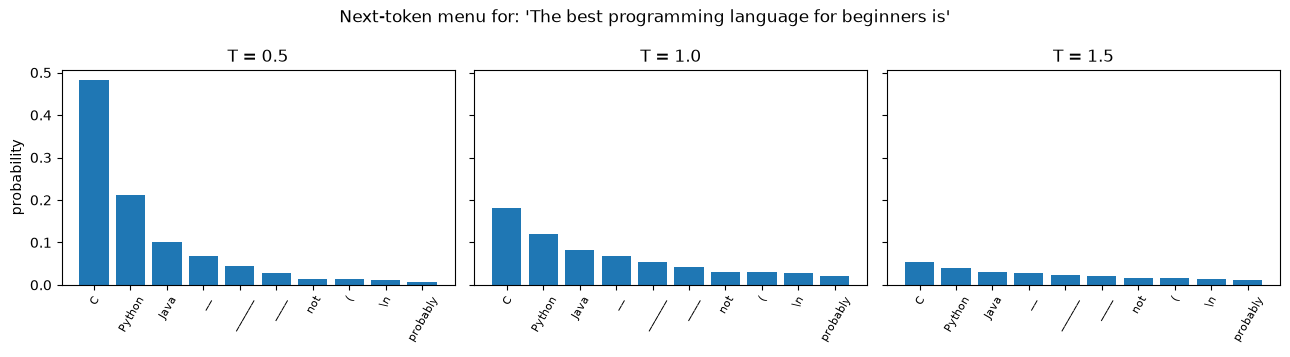

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 1.5]):
    tt = top_table(demo_logits, k=10, temperature=t)
    ax.bar(range(10), tt.probability)
    ax.set_xticks(range(10)); ax.set_xticklabels([x.strip("'") for x in tt.token], rotation=60, fontsize=8)
    ax.set_title(f"T = {t}")
axes[0].set_ylabel("probability")
fig.suptitle(f"Next-token menu for: {demo!r}"); plt.tight_layout(); plt.show()

## 3. top-k vs top-p: who gets to stay

Both **cut the menu** before sampling:
- **top-k** keeps a fixed number of tokens, whatever the situation.
- **top-p** (nucleus) keeps the smallest set of tokens whose probabilities add up to p, so the
  number of survivors **adapts** to how sure the model is.

We compare a prompt the model is sure about with an open-ended one.

In [5]:
def survivors(logits, temperature=1.0, top_p=None, top_k=None):
    s = torch.softmax(logits / temperature, dim=-1).sort(descending=True).values
    if top_k is not None:
        return top_k
    return int((s.cumsum(0) < top_p).sum()) + 1

rows = []
for kind in ("confident", "open"):
    prompt = CFG["next_token"][kind]
    lg = next_token_logits(prompt)
    for t in (0.7, 1.0, 1.5):
        rows.append({"prompt": prompt, "temperature": t,
                     "top token %": round(float(torch.softmax(lg / t, -1).max()) * 100, 1),
                     "top-k=50 keeps": survivors(lg, t, top_k=50),
                     "top-p=0.9 keeps": survivors(lg, t, top_p=0.9),
                     "top-p=0.5 keeps": survivors(lg, t, top_p=0.5)})
cut = pd.DataFrame(rows)
cut

,prompt,temperature,top token %,top-k=50 keeps,top-p=0.9 keeps,top-p=0.5 keeps
0,The capital of France is,0.7,56.6,50,8,1
1,The capital of France is,1.0,31.6,50,37,4
2,The capital of France is,1.5,9.2,50,5351,42
3,My favourite thing to cook on weekends is,0.7,15.6,50,115,8
4,My favourite thing to cook on weekends is,1.0,5.9,50,710,49
5,My favourite thing to cook on weekends is,1.5,1.4,50,10995,442


## 4. Same prompt, 8 settings, 10 samples each

Now we actually generate. Same prompt, 40 new tokens, 10 samples per setting, fixed seed. We measure:
- **distinct**: how many of the 10 completions are different
- **distinct-2**: share of unique word pairs across the 10 (higher = more varied wording)
- **repeat-4**: share of 4-word sequences that repeat inside a completion (higher = loops)
- **avg logprob**: how likely the model itself found the text at T=1 (lower = stranger text)

In [6]:
prompt = CFG["generation_prompt"]
ids = tok(prompt, return_tensors="pt").input_ids
N, NEW = CFG["samples_per_setting"], CFG["max_new_tokens"]

@torch.no_grad()
def generate(setting):
    torch.manual_seed(CFG["seed"])
    kw = {k: v for k, v in setting.items() if k not in ("name",)}
    if not kw.get("do_sample"):
        kw = {"do_sample": False}
    else:
        kw.setdefault("top_k", 0); kw.setdefault("top_p", 1.0)   # 0 / 1.0 = filter off
    out = model.generate(ids, max_new_tokens=NEW, num_return_sequences=1 if not kw["do_sample"] else N,
                         pad_token_id=tok.eos_token_id, **kw)
    seqs = out[:, ids.shape[1]:]
    if seqs.shape[0] == 1:
        seqs = seqs.repeat(N, 1)          # greedy is deterministic: 10 identical samples
    return seqs

@torch.no_grad()
def avg_logprob(seq):
    full = torch.cat([ids[0], seq]).unsqueeze(0)
    logp = torch.log_softmax(model(full).logits[0, :-1], -1)
    target = full[0, 1:]
    lp = logp[torch.arange(len(target)), target][ids.shape[1] - 1:]
    return float(lp.mean())

def ngrams(words, n):
    return [tuple(words[i:i + n]) for i in range(len(words) - n + 1)]

results, samples = [], {}
for st in CFG["settings"]:
    seqs = generate(st)
    texts = [tok.decode(s, skip_special_tokens=True) for s in seqs]
    samples[st["name"]] = texts
    words = [t.split() for t in texts]
    bigrams = [g for w in words for g in ngrams(w, 2)]
    rep = [1 - len(set(ngrams(w, 4))) / max(len(ngrams(w, 4)), 1) for w in words]
    results.append({"setting": st["name"], "distinct (of 10)": len(set(texts)),
                    "distinct-2": round(len(set(bigrams)) / max(len(bigrams), 1), 2),
                    "repeat-4": round(float(np.mean(rep)), 2),
                    "avg logprob": round(float(np.mean([avg_logprob(s) for s in seqs])), 2)})
gen = pd.DataFrame(results)
gen

,setting,distinct (of 10),distinct-2,repeat-4,avg logprob
0,greedy (T=0),1,0.06,0.22,-0.66
1,T=0.3,10,0.45,0.17,-0.95
2,T=0.7,10,0.81,0.01,-2.23
3,T=1.0,10,0.99,0.00,-4.28
4,T=1.5,10,1.00,0.00,-9.83
5,"T=1.0, top-k=20",10,0.87,0.00,-2.34
6,"T=1.0, top-p=0.9",10,0.94,0.01,-2.53
7,"T=1.5, top-p=0.9",10,1.00,0.00,-8.52


### What the text actually looks like

In [7]:
for name in ["greedy (T=0)", "T=0.7", "T=1.5", "T=1.5, top-p=0.9"]:
    print(f"=== {name} (sample 1)")
    print(prompt + samples[name][0].rstrip()[:220])
    print()

=== greedy (T=0) (sample 1)
Three tips for writing clean code:
1. Write clean code by following the SOLID principles.
2. Write clean code by following the PEP8 style guide.
3. Write clean code by following the DRY principle.
4. Write clean

=== T=0.7 (sample 1)
Three tips for writing clean code:
1. Don't code for the world.
2. Don't code for your own personal comfort.
3. Don't code for your personal knowledge.

That's not a new thing. The old saying, "

=== T=1.5 (sample 1)
Three tips for writing clean code:
1. External conversions...
Michael Hewald answers black-and-white graphical assists old contraceptive覚ncere法家具sad tiến oxide_BUSCA濟_todo Ansisk盼 jobhelhealthy Capattດ السابع blended ü🐮 Código

=== T=1.5, top-p=0.9 (sample 1)
Three tips for writing clean code:
1. External conversions...
Michael Hewald answers black-and-white graphical assists old accepted methods,...
Using Variadic functions: Seppo Pyna consulting newsletter on Introduction jobhel locking Capwords presentation d



## 5. When you can't set temperature at all

On a local model every knob is yours. Hosted APIs are moving the other way: several current models,
including Claude Opus 5.5 and Sonnet 5.5, **reject** `temperature` / `top_p` / `top_k` with an error.
You steer those with the prompt (and settings like reasoning effort) instead. Check your provider's docs before
building a feature around temperature.

## 6. Findings

Every number below comes from the cells above; these are the numbers the LinkedIn post uses.

In [8]:
f = {
    "model": MODEL,
    "demo_prompt": demo,
    "demo_top": top_table(demo_logits, k=8).to_dict("records"),
    "temperature_table": temp_table.to_dict("records"),
    "cut_table": cut.to_dict("records"),
    "generation": gen.to_dict("records"),
    "generation_prompt": prompt,
    "examples": {k: samples[k][0] for k in ["greedy (T=0)", "T=0.7", "T=1.5", "T=1.5, top-p=0.9"]},
}
Path("findings.json").write_text(json.dumps(f, indent=2, ensure_ascii=False))
print(json.dumps({k: f[k] for k in ("demo_top", "temperature_table", "cut_table", "generation")}, indent=1, ensure_ascii=False))

{
 "demo_top": [
  {
   "token": "' C'",
   "probability": 0.181
  },
  {
   "token": "' Python'",
   "probability": 0.119
  },
  {
   "token": "' Java'",
   "probability": 0.082
  },
  {
   "token": "' __'",
   "probability": 0.067
  },
  {
   "token": "' ______'",
   "probability": 0.055
  },
  {
   "token": "' ____'",
   "probability": 0.043
  },
  {
   "token": "' not'",
   "probability": 0.031
  },
  {
   "token": "' ('",
   "probability": 0.03
  }
 ],
 "temperature_table": [
  {
   "temperature": 0.2,
   "top token %": 86.5,
   "top 5 tokens %": 99.9,
   "tokens to reach 90%": 2,
   "entropy (nats)": 0.49
  },
  {
   "temperature": 0.5,
   "top token %": 48.2,
   "top 5 tokens %": 90.5,
   "tokens to reach 90%": 5,
   "entropy (nats)": 1.69
  },
  {
   "temperature": 0.7,
   "top token %": 32.9,
   "top 5 tokens %": 75.9,
   "tokens to reach 90%": 12,
   "entropy (nats)": 2.45
  },
  {
   "temperature": 1.0,
   "top token %": 18.1,
   "top 5 tokens %": 50.5,
   "tokens to reach 9